In [33]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from front_finding import buildconfig
from front_finding.cli import build_fronts
from front_finding.llc import source as llc_source

CONFIG = Path("../configs/run/small_fronts_dataset_00.yaml")
assert CONFIG.is_file(), f"run this from notebooks/ -- {CONFIG} not found"

cfg = buildconfig.load_config(CONFIG)

TIMESTAMP = cfg.timestamps[0]

In [34]:
cfg.finding

FindingConfig(build_version='SMALL_DATASET', config='D', gradb2_root='gradb2', suffix='sfc', ice_mask_find=False, ice_mask_props=False, properties_dilation_radius=2, properties_stats=['mean', 'std', 'min', 'max', 'skew'], properties_nan_policy='omit', properties_cross_front_radius=0, dilate_only_to_front_pixels=True, percentiles=[25, 75, 90], exclude_roots=[], save_unprocessed_binary=True, clobber={'find': False, 'group': False, 'colocate': False, 'push': False})

## Run

One call, four steps:

| step | does |
|---|---|
| `gradb2` | build `frontal_structure.zarr` if it is missing (a dbof run) |
| `find` | threshold gradb2 into a binary front map |
| `group` | label the fronts, measure their geometry |
| `colocate` | sample the subset's other 7 channels onto each front |

`frontal_structure` carries `gradb2, gradsalt2, gradtheta2, gradeta2,
gradrho2, turner_angle, density, buoyancy`, so `colocate` costs no extra
generation — every field is already in the store built by the first step, and
is read from it directly.

Drop steps from the list to re-run part of it.

In [ ]:
build_fronts.run(cfg, ["gradb2", "find", "group", "colocate"])
#build_fronts.run(cfg, ["colocate"])

pipeline=SURF  run_id=v2_2_01  dates=5  gradb2=gradb2 (subset=frontal_structure)  finding_config=D
steps=['gradb2', 'find', 'group', 'colocate']
store -> /Users/jaketallman/PycharmProjects/front-finding/output/SMALL_DATASET/SURF/fronts.zarr
  SKIP (store serves gradb2)  frontal_structure
Running: /Users/jaketallman/PycharmProjects/front-finding/.venv/bin/python -m dbof.cli.run_all_subsets --config /var/folders/kr/y4zmny8x7tlbdrx9d7bkt0l00000gn/T/dbof_source_xx6ro9vr.yaml --netcdf-base /Users/jaketallman/PycharmProjects/front-finding/output/SMALL_DATASET/SURF --generate-only


2026-09-15 11:18:55 | INFO | Pipeline: SURF  |  run_id: v2_2_01  |  dates: 5  |  subsets: 5
2026-09-15 11:18:55 | INFO |   frontal_structure  (frontal_structure.zarr, 8 channels)
2026-09-15 11:18:55 | INFO |   icearea  (icearea.zarr, 1 channels)
2026-09-15 11:18:55 | INFO |   kinematic  (kinematic.zarr, 8 channels)
2026-09-15 11:18:55 | INFO |   native_fields  (native_fields.zarr, 6 channels)
2026-09-15 11:18:55 | INFO |   surface_wind  (surface_wind.zarr, 7 channels)
2026-09-15 11:18:56 | INFO | Found credentials in shared credentials file: ~/.aws/credentials
2026-09-15 11:19:05 | INFO | 
2026-09-15 11:19:05 | INFO | WORK PLAN (.nc-first: check .nc -> check zarr -> generate/export)
2026-09-15 11:19:05 | INFO |   frontal_structure      20111216_030000  SKIP     
2026-09-15 11:19:05 | INFO |   frontal_structure      20120104_110000  SKIP     
2026-09-15 11:19:05 | INFO |   frontal_structure      20120208_230000  SKIP     
2026-09-15 11:19:05 | INFO |   frontal_structure      20120319_10

Resolved 30 channels to co-locate
[2011-12-16T03_00_00]
[20111216_030000] fronts already found; pass clobber=True to redo
[20111216_030000] fronts already grouped; pass clobber=True to redo
[20111216_030000] already co-located; pass clobber=True to redo
[2012-01-04T11_00_00]
[20120104_110000] fronts already found; pass clobber=True to redo
[20120104_110000] fronts already grouped; pass clobber=True to redo


Reading channels:   0%|          | 0/30 [00:00<?, ?ch/s, gradb2]

front id: 77850
front 20111216TT030000_1.5S_70.0E   (label 77850)   20111216_030000
  4,712.3 km | 1,949 px | 241 branches | centroid -1.50, 69.96
labels: 
[     0      1      2 ... 127625 127626 127627]

--- geometry ---
label                                        77850
name                   20111216TT030000_1.5S_70.0E
time                           2011-12-16T03:00:00
npix                                          1949
y0                                            7673
y1                                            7975
x0                                            4862
x1                                            5599
centroid_lat                             -1.498694
centroid_lon                              69.95993
length_km                              4712.349609
orientation                               72.42337
num_branches                                   241
lat_min                                  -4.758078
lat_max                                    1.05478
lon_min      

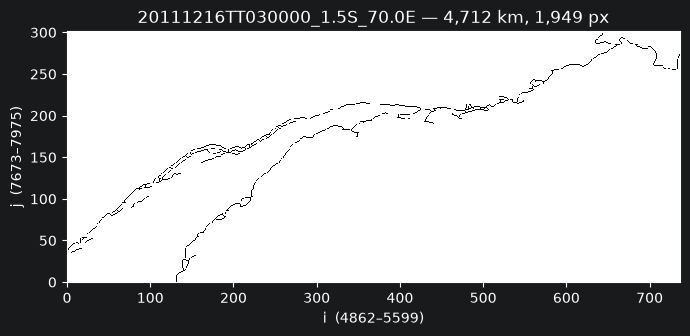

In [22]:
from front_finding.store import FrontStore

STORE = "../output/SMALL_DATASET/SURF/fronts.zarr"   # from notebooks/; adjust if elsewhere
LABEL = None                                   # None -> the longest front

store = FrontStore.open(STORE)
DATE = store.dates[0]

# --- pick the front --------------------------------------------------------
fronts = store.fronts(DATE, cross=True)                    # geometry joined to properties
if LABEL is None:
    LABEL = int(fronts.loc[fronts["length_km"].idxmax(), "label"])
print(f"front id: {LABEL}")
front = fronts[fronts["label"] == LABEL].iloc[0]

# geometry columns are whatever `group` wrote; the rest are {channel}_{stat}
geom_cols = list(store.geometry(DATE).columns)
STATS = ["mean", "std", "min", "max", "skew"]
prop_cols = [c for c in fronts.columns
             if c not in geom_cols and c.rsplit("_", 1)[-1] in STATS]

print(f"front {front['name']}   (label {LABEL})   {DATE}")
print(f"  {front['length_km']:,.1f} km | {int(front['npix']):,} px | "
      f"{front['num_branches']} branches | "
      f"centroid {front['centroid_lat']:.2f}, {front['centroid_lon']:.2f}")

print("labels: ")
print(np.unique(store.labels(DATE)))

# --- geometry --------------------------------------------------------------
print("\n--- geometry ---")
print(front[geom_cols].to_string())

# # --- properties, as channel x statistic ------------------------------------
print(f"\n--- properties ({len(prop_cols)} columns) ---")
table = pd.DataFrame({
    "channel": [c.rsplit("_", 1)[0] for c in prop_cols],
    "stat":    [c.rsplit("_", 1)[1] for c in prop_cols],
    "value":   front[prop_cols].astype(float).values,
}).pivot(index="channel", columns="stat", values="value")
print(table[list(STATS)].to_string(float_format=lambda v: f"{v:12.4g}"))

# gradients span ~1e-13 to 1e-7, so context matters when reading these
ca = store.step_attrs(DATE, "colocate")
print(f"\nsampled over each front dilated by {ca.get('properties_dilation_radius')} px, "
      f"nan_policy={ca.get('nan_policy')!r}")

# --- its pixels ------------------------------------------------------------
win = (int(front.y0), int(front.y1), int(front.x0), int(front.x1))
mask = store.labels(DATE, window=win) == LABEL   # reads only this window
print(f"\nbbox {win} -> {mask.shape} window, {int(mask.sum()):,} px are this front")

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(mask, origin="lower", cmap="Greys", interpolation="nearest")
ax.set_title(f"{front['name']} — {front['length_km']:,.0f} km, "
             f"{int(front['npix']):,} px")
ax.set_xlabel(f"i  ({win[2]}–{win[3]})")
ax.set_ylabel(f"j  ({win[0]}–{win[1]})")
fig.tight_layout()

In [25]:
print( list(store.fronts(DATE).columns) )

['label', 'name', 'time', 'npix', 'y0', 'y1', 'x0', 'x1', 'centroid_lat', 'centroid_lon', 'length_km', 'orientation', 'num_branches', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'mean_curvature', 'curvature_direction', 'npix_prop', 'gradb2_mean', 'gradb2_std', 'gradb2_min', 'gradb2_max', 'gradb2_skew', 'gradb2_p25', 'gradb2_p75', 'gradb2_p90', 'gradsalt2_mean', 'gradsalt2_std', 'gradsalt2_min', 'gradsalt2_max', 'gradsalt2_skew', 'gradsalt2_p25', 'gradsalt2_p75', 'gradsalt2_p90', 'gradtheta2_mean', 'gradtheta2_std', 'gradtheta2_min', 'gradtheta2_max', 'gradtheta2_skew', 'gradtheta2_p25', 'gradtheta2_p75', 'gradtheta2_p90', 'gradeta2_mean', 'gradeta2_std', 'gradeta2_min', 'gradeta2_max', 'gradeta2_skew', 'gradeta2_p25', 'gradeta2_p75', 'gradeta2_p90', 'gradrho2_mean', 'gradrho2_std', 'gradrho2_min', 'gradrho2_max', 'gradrho2_skew', 'gradrho2_p25', 'gradrho2_p75', 'gradrho2_p90', 'turner_angle_mean', 'turner_angle_std', 'turner_angle_min', 'turner_angle_max', 'turner_angle_skew', 'turner_

In [8]:
store.attrs

{'build_version': 'SMALL_DATASET',
 'pipeline': 'SURF',
 'run_id': 'v2_2_01',
 'config_file': '/Users/jaketallman/PycharmProjects/front-finding/configs/run/small_fronts_dataset_00.yaml',
 'source_bucket': 'dbof/',
 'source_folder': 'globals_for_cutouts/',
 'finding_config': 'D',
 'gradb2_channel': 'gradb2',
 'gradb2_subset': 'frontal_structure',
 'dates': ['2011-12-16 03:00:00', '2012-01-04 11:00:00']}

In [9]:
import numpy as np
import matplotlib.pyplot as plt


def plot_property_distribution(store, date, col, log=True, bins=60, ax=None):
    """Histogram one per-front property.

    Parameters
    ----------
    store : FrontStore
    date : str
        Snapshot group, ``YYYYMMDD_HHMMSS``.
    col : str
        A column of the properties table, e.g. ``'gradb2_mean'``.
    log : bool
        Log-spaced bins and log axes.  Non-positive values are dropped, since
        they cannot be plotted on a log scale -- the count appears in the title.
    bins : int
    ax : matplotlib Axes, optional
        Draw into an existing axes instead of making a figure.

    Returns
    -------
    matplotlib.axes.Axes
    """
    v = store.fronts(date, cross=True)[col].astype(float).values
    n_read = v.size
    v = v[np.isfinite(v)]
    if log:
        v = v[v > 0]
    if v.size == 0:
        raise ValueError(f"{col} has no plottable values in {date}")

    edges = (np.logspace(np.log10(v.min()), np.log10(v.max()), bins) if log
             else np.linspace(v.min(), v.max(), bins))

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    ax.hist(v, bins=edges, color="steelblue", edgecolor="white", linewidth=0.4)
    if log:
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.set_xlabel(col)
    ax.set_ylabel("fronts")
    ax.grid(alpha=0.3, which="both")

    med = np.median(v)
    ax.axvline(med, color="crimson", ls="--", lw=1)
    ax.text(med, ax.get_ylim()[1], f"  median {med:.3g}", color="crimson",
            va="top", fontsize=9)

    dropped = n_read - v.size
    ax.set_title(f"{col} — {v.size:,} fronts, {date}"
                 + (f"  ({dropped} dropped)" if dropped else ""))
    ax.figure.tight_layout()
    return ax

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
import cmocean.cm as cmo
from scipy import ndimage

from dbof.global_dataset_creation.subset_definitions import get_subset_definition
from dbof.global_dataset_creation.zarr_dataset_global import GlobalZarrDatasetReader
from dbof.io.filesystems import create_s3_filesystems
from dbof.plotting.field_cmaps import load_field_cmaps

from front_finding import buildconfig
from front_finding.properties.colocation import _dilate_labeled_array


def _read_window(cfg, timestamp, channel, subset, window):
    """One channel over one bounding box, straight from the source zarr.

    reader.data is a zarr array, so slicing it touches only the overlapping
    chunks -- the full snapshot is ~900 MB.
    """
    y0, y1, x0, x1 = window
    dataset_name = (cfg.source.dataset_name
                    or get_subset_definition(cfg.pipeline, subset)['dataset_name'])
    fs, _ = create_s3_filesystems(cfg.source.s3_endpoint)
    date_prefix = cfg.date_prefixes[cfg.timestamps.index(timestamp)]
    reader = GlobalZarrDatasetReader(
        bucket=cfg.source.bucket, folder=cfg.source.folder, run_id=cfg.run_id,
        dataset_name=dataset_name, fs=fs, date_prefix=date_prefix)
    c = reader.channel_names.index(channel)
    return np.asarray(reader.data[c, y0:y1, x0:x1])


def plot_front_dilation(store, label, date=None, pad=8, cross_radius=None,
                        ax=None, show_cross=True, show_dilation=True):
    """One front over gradb2, with the pixels co-location actually sampled.

    White is the front, grey its own band, green the cross-front band, blue the
    neighbouring fronts, purple the threshold pixels post-processing threw
    away (absent from stores built before binary_unprocessed was kept).  Both
    bands are built the way colocate builds them: _dilate_labeled_array for the
    first, distance-to-this-front-alone for the second, at the radii recorded
    in the store.

    When the run set dilate_only_to_front_pixels, the band is masked to the
    threshold map here too, so the picture matches what colocate sampled.

    cross_radius overrides the stored cross-front radius, so a candidate value
    can be previewed before a run commits to it.
    """
    date = date or store.dates[0]
    geom = store.geometry(date)
    front = geom[geom["label"] == label].iloc[0]

    ca = store.step_attrs(date, "colocate")
    radius = int(ca.get("properties_dilation_radius",
                        ca.get("dilation_radius", 0)))
    if cross_radius is None:
        cross_radius = int(ca.get("properties_cross_front_radius", 0))
    outer = radius + cross_radius

    # Halo so the dilation is computed with the same neighbours it had
    # globally -- an adjacent front can claim background this one would else.
    ny, nx = store.labels(date).shape
    halo = pad + outer
    win = (max(int(front.y0) - halo, 0), min(int(front.y1) + halo, ny),
           max(int(front.x0) - halo, 0), min(int(front.x1) + halo, nx))

    crop = np.asarray(store.labels(date, window=win))
    present = np.unique(crop)
    present = present[present > 0]
    # binary_unprocessed serves twice: the purple layer below, and the mask
    # when the run restricted the band to threshold pixels.
    try:
        raw = np.asarray(store.binary_unprocessed(date, window=win))
    except KeyError:
        raw = None
    masked = bool(ca.get("dilate_only_to_front_pixels", False)) and raw is not None
    mask = raw if masked else None

    dilated = _dilate_labeled_array(crop, present, radius, mask=mask)

    is_front = crop == label
    is_band = (dilated == label) & ~is_front
    # The neighbours are what makes the band asymmetric: _dilate_labeled_array
    # gives each background pixel to its NEAREST front, so they carve into it.
    others = (crop > 0) & ~is_front
    other_band = (dilated > 0) & (dilated != label) & ~others

    # The cross-front band, exactly as cross_front_properties builds it:
    # distance to THIS front alone, minus everything the first pass sampled.
    # It may overlap neighbouring fronts -- that is the point of it.
    is_cross = np.zeros_like(is_front)
    if cross_radius > 0:
        dist = ndimage.distance_transform_edt(crop != label)
        is_cross = (dist <= outer) & (dilated != label)

    # Threshold pixels no surviving front occupies -- what sharpening,
    # thinning, cropping and spur removal discarded.
    discarded = raw & (crop == 0) if raw is not None else None

    # Two baselines, so the band's losses split cleanly: the mask costs
    # (free -> solo), the neighbours cost the rest (solo -> band).
    alone = np.where(is_front, crop, 0)
    solo = _dilate_labeled_array(alone, np.array([label]), radius, mask=mask)
    isolated = int(((solo == label) & ~is_front).sum())
    unmasked = _dilate_labeled_array(alone, np.array([label]), radius)
    isolated_free = int(((unmasked == label) & ~is_front).sum())

    cfg = buildconfig.load_config(store.attrs["config_file"])
    timestamp = cfg.timestamps[cfg.date_prefixes.index(date)]
    channel = store.attrs["gradb2_channel"]
    field = _read_window(cfg, timestamp, channel,
                         store.attrs["gradb2_subset"], win)

    cmaps, _ = load_field_cmaps()
    cmap_name, cbar_label = cmaps[channel]

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 8))
    finite = field[np.isfinite(field) & (field > 0)]
    im = ax.imshow(field, origin="lower", cmap=getattr(cmo, cmap_name),
                   norm=LogNorm(vmin=np.percentile(finite, 2),
                                vmax=np.percentile(finite, 99.5)),
                   interpolation="nearest")
    if discarded is not None:
        ax.imshow(np.ma.masked_where(~discarded, discarded), origin="lower",
                  cmap=ListedColormap(["#805ad5"]), vmin=0, vmax=1,
                  interpolation="nearest", alpha=1)
    if show_cross:
        ax.imshow(np.ma.masked_where(~is_cross, is_cross), origin="lower",
                  cmap=ListedColormap(["#38a169"]), vmin=0, vmax=1,
                  interpolation="nearest", alpha=0.30)
    if show_dilation:
        ax.imshow(np.ma.masked_where(~other_band, other_band), origin="lower",
                  cmap=ListedColormap(["#2b6cb0"]), vmin=0, vmax=1,
                  interpolation="nearest", alpha=0.28)
        ax.imshow(np.ma.masked_where(~is_band, is_band), origin="lower",
                  cmap=ListedColormap(["0.55"]), vmin=0, vmax=1,
                  interpolation="nearest", alpha=0.85)
    ax.imshow(np.ma.masked_where(~others, others), origin="lower",
              cmap=ListedColormap(["#2b6cb0"]), vmin=0, vmax=1,
              interpolation="nearest")
    ax.imshow(np.ma.masked_where(~is_front, is_front), origin="lower",
              cmap=ListedColormap(["white"]), vmin=0, vmax=1,
              interpolation="nearest")

    band_px = int(is_band.sum())
    lost = isolated - band_px
    mask_line = ""
    if masked:
        mask_line = (f"\nband masked to threshold pixels: "
                     f"{isolated_free - isolated:,} px dropped of "
                     f"{isolated_free:,} geometric")
    raw_line = ""
    if discarded is not None:
        kept = int(is_front.sum()) + int(others.sum())
        raw_line = (f"\npurple = {int(discarded.sum()):,} threshold px discarded "
                    f"by post-processing ({kept:,} kept in this window)")
    cross_line = ""
    if cross_radius > 0:
        cross_line = (
            f"\ncross radius {cross_radius} (out to {outer} px): "
            f"{int(is_cross.sum()):,} px, "
            f"{int((is_cross & others).sum()):,} of them on other fronts")
    ax.set_title(
        f"{front['name']} — {front['length_km']:,.0f} km, "
        f"{int(front['npix']):,} px\n"
        f"white = front, grey = its band, green = cross-front band, "
        f"blue = neighbouring fronts\n"
        f"radius {radius}: {band_px:,} px sampled of {isolated:,} isolated "
        f"({lost:,} claimed by {len(present) - 1} neighbours)"
        + mask_line + cross_line + raw_line, fontsize=9)
    ax.set_xlabel(f"i  ({win[2]}–{win[3]})")
    ax.set_ylabel(f"j  ({win[0]}–{win[1]})")
    cb = ax.figure.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label(cbar_label)
    ax.figure.tight_layout()
    return ax

In [11]:
print(fronts[fronts["length_km"] == fronts["length_km"].min()])

      label                          name                 time  npix    y0  \
5656   3105  20111216TT030000_73.6S_35.5W  2011-12-16T03:00:00     8  2474   

        y1   x0   x1  centroid_lat  centroid_lon  ...  v_ekman_p75  \
5656  2479  126  129    -73.615112     -35.47414  ...     0.161462   

      v_ekman_p90  oceQnet_mean  oceQnet_std  oceQnet_min  oceQnet_max  \
5656     0.169979       0.84115     0.736787    -0.097214     3.041878   

      oceQnet_skew  oceQnet_p25  oceQnet_p75  oceQnet_p90  
5656      1.261102     0.223352      1.13425     1.795796  

[1 rows x 260 columns]


<Axes: title={'center': '20111216TT030000_77.9S_166.1W — 54 km, 87 px\nwhite = front, grey = its band, green = cross-front band, blue = neighbouring fronts\nradius 2: 132 px sampled of 132 isolated (0 claimed by 11 neighbours)\nband masked to threshold pixels: 220 px dropped of 352 geometric\npurple = 528 threshold px discarded by post-processing (311 kept in this window)'}, xlabel='i  (10942–11033)', ylabel='j  (1806–1872)'>

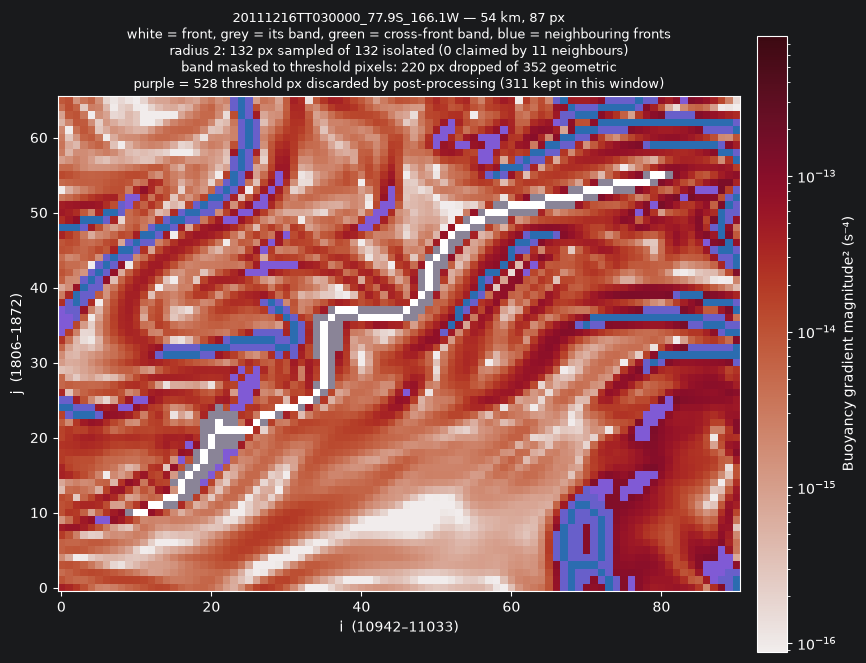

In [13]:
plot_front_dilation(store, 20, show_cross=False, show_dilation=True)# 10)

<Axes: title={'center': '20111204TT000000_39.2S_15.5E — 2,280 km, 1,257 px\nwhite = front, grey = its band, green = cross-front band, blue = neighbouring fronts\nradius 2: 4,687 px sampled of 4,699 isolated (12 claimed by 102 neighbours)\ncross radius 8 (out to 10 px): 15,957 px, 206 of them on other fronts\npurple = 11,500 threshold px discarded by post-processing (4,946 kept in this window)'}, xlabel='i  (2439–2794)', ylabel='j  (5541–5856)'>

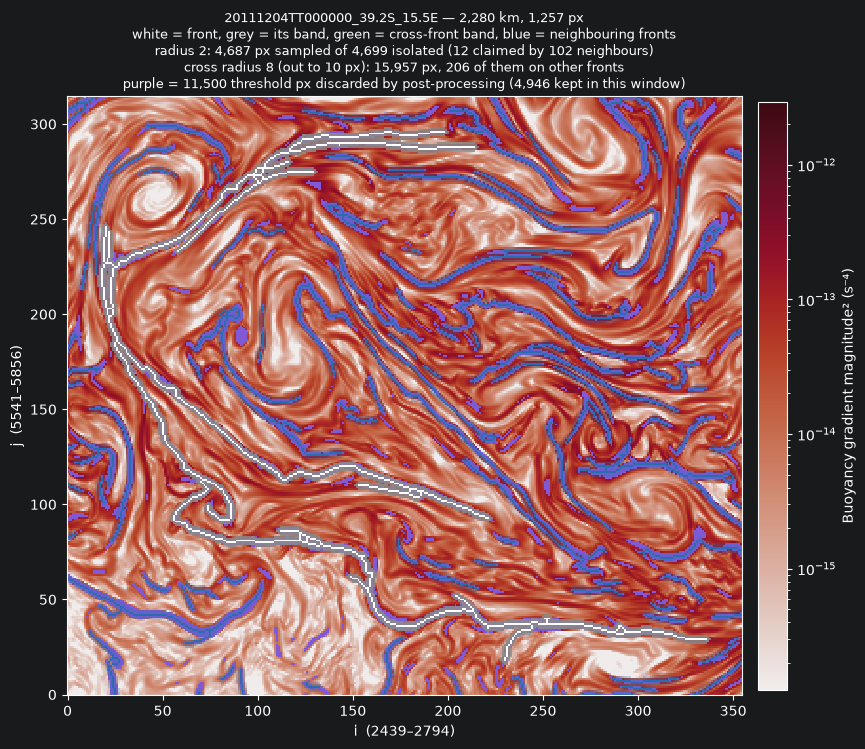

In [11]:
plot_front_dilation(store, 42920, show_cross=False, show_dilation=True)

In [26]:
fronts[fronts["length_km"] == fronts["length_km"].max()].label

44035    42920
Name: label, dtype: int32

In [19]:
store

In [21]:
store.geometry(DATE)

,label,name,time,npix,y0,y1,x0,x1,centroid_lat,centroid_lon,length_km,orientation,num_branches,lat_min,lat_max,lon_min,lon_max,mean_curvature,curvature_direction
0,6697,20111204TT000000_69.0S_25.2E,2011-12-04T00:00:00,19,3000,3016,3029,3043,-69.044296,25.216557,18.248856,41.328976,0,-69.109230,-68.996338,25.114584,25.385416,0.028623,-0.028623
1,6698,20111204TT000000_69.0S_104.9W,2011-12-04T00:00:00,57,3000,3015,14048,14091,-69.052765,-104.886513,47.543007,76.904396,8,-69.109230,-69.003876,-105.322914,-104.447914,0.304734,0.024616
2,6699,20111204TT000000_69.1S_83.8W,2011-12-04T00:00:00,10,3000,3005,15077,15087,-69.095695,-83.791672,8.614378,66.851402,0,-69.109230,-69.079170,-83.885414,-83.697914,NaN,NaN
3,6700,20111204TT000000_69.0S_58.6W,2011-12-04T00:00:00,47,3000,3030,16283,16300,-68.994835,-58.590649,42.508064,20.276083,7,-69.109230,-68.890556,-58.760418,-58.427082,0.240192,-0.009341
4,6701,20111204TT000000_69.1S_58.1W,2011-12-04T00:00:00,8,3000,3006,16311,16316,-69.086685,-58.119789,6.650859,39.588493,0,-69.109230,-69.071648,-58.177082,-58.093750,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111649,111596,20111204TT000000_71.0N_164.3E,2011-12-04T00:00:00,11,12950,12959,9904,9910,70.953918,164.325699,11.386785,30.677908,0,70.925705,70.981461,164.242767,164.402878,0.128133,0.128133
111650,111597,20111204TT000000_72.0N_172.4W,2011-12-04T00:00:00,24,12950,12958,10810,10834,71.986389,-172.422012,22.185205,73.417953,0,71.960190,72.020218,-172.724411,-172.118866,0.072849,-0.054856
111651,111598,20111204TT000000_69.4N_138.0W,2011-12-04T00:00:00,15,12950,12960,12260,12269,69.384300,-137.953278,11.132677,41.476246,0,69.355118,69.430763,-137.985840,-137.880371,0.139150,0.085923
111652,111599,20111204TT000000_71.1N_14.0W,2011-12-04T00:00:00,27,12951,12960,1326,1348,71.112198,-14.013580,26.449537,72.968994,0,71.072304,71.169312,-14.272949,-13.780986,0.236001,-0.017337


<Axes: title={'center': '20111204TT000000_36.6S_20.6E — 246 km, 127 px\nwhite = front, grey = its band, green = cross-front band, blue = neighbouring fronts\nradius 2: 232 px sampled of 232 isolated (0 claimed by 9 neighbours)\nband masked to threshold pixels: 242 px dropped of 474 geometric\ncross radius 8 (out to 10 px): 1,836 px, 9 of them on other fronts\npurple = 679 threshold px discarded by post-processing (219 kept in this window)'}, xlabel='i  (2763–2861)', ylabel='j  (5837–5910)'>

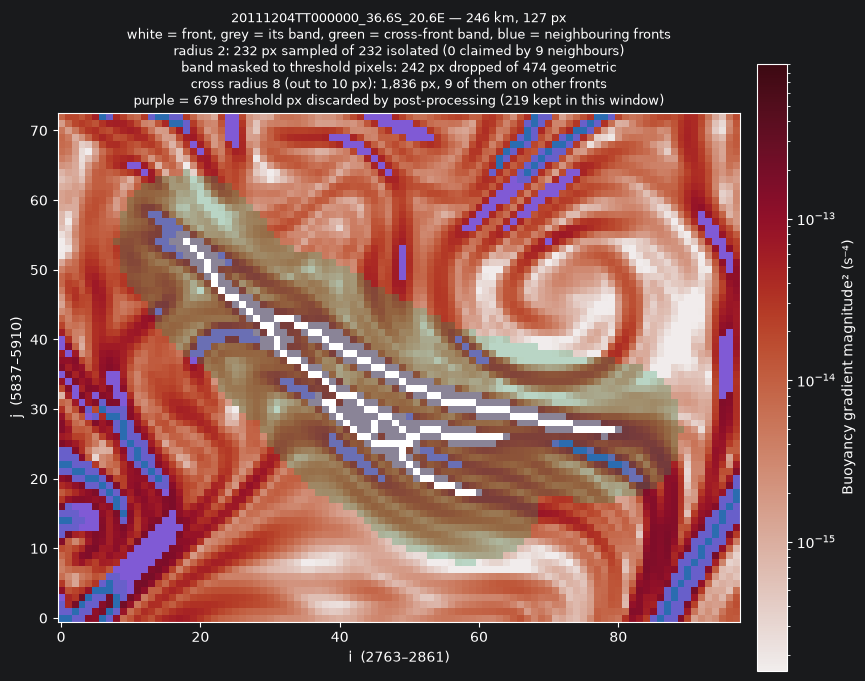

In [19]:
plot_front_dilation(store, 47356)

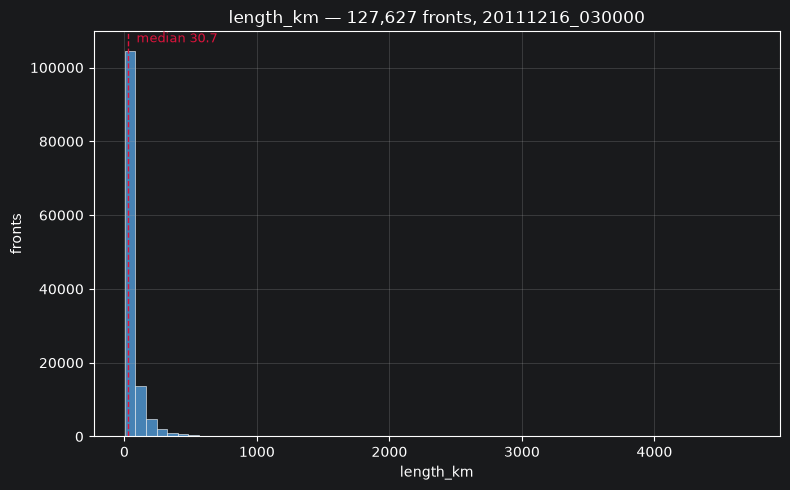

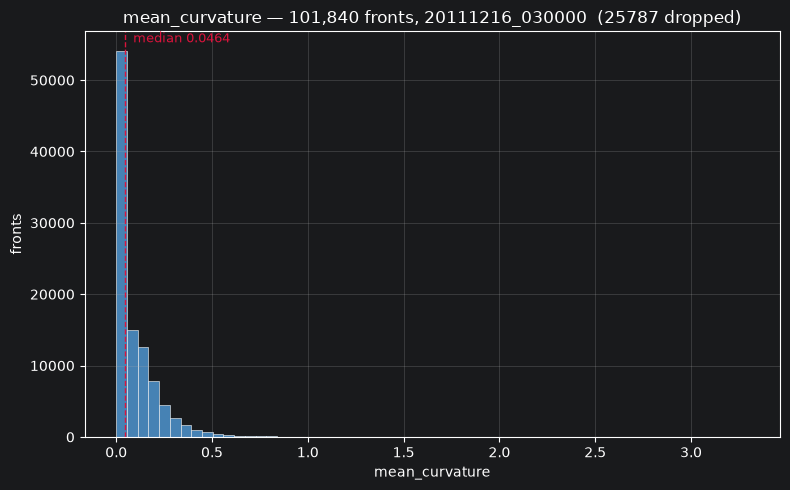

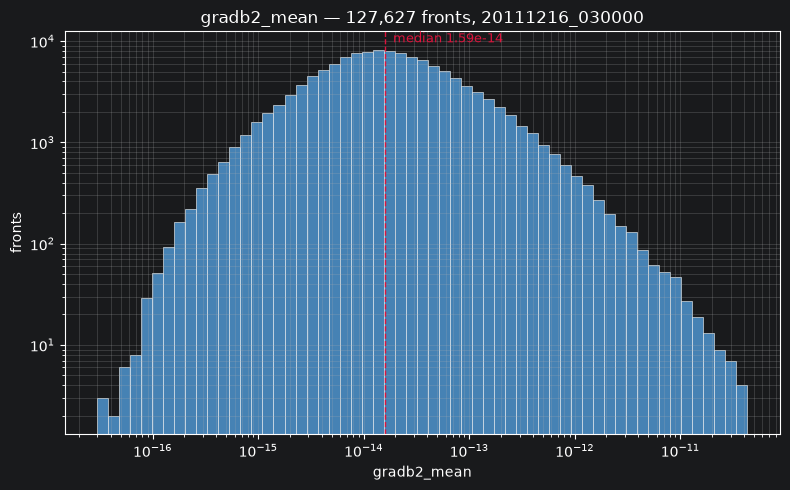

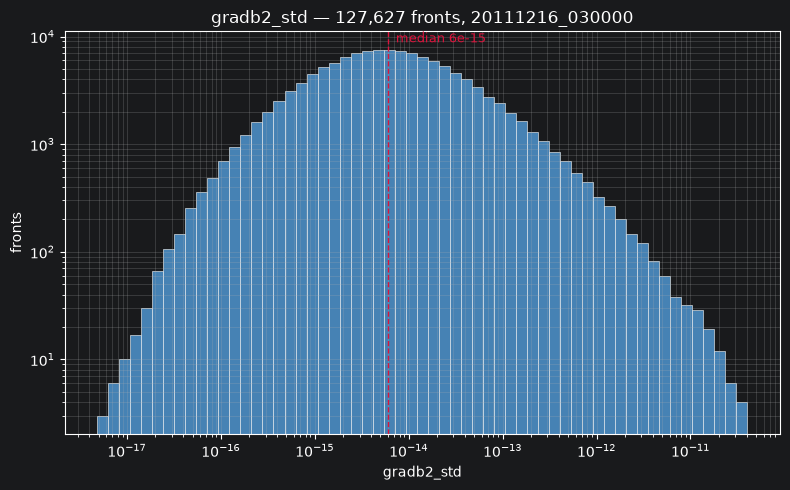

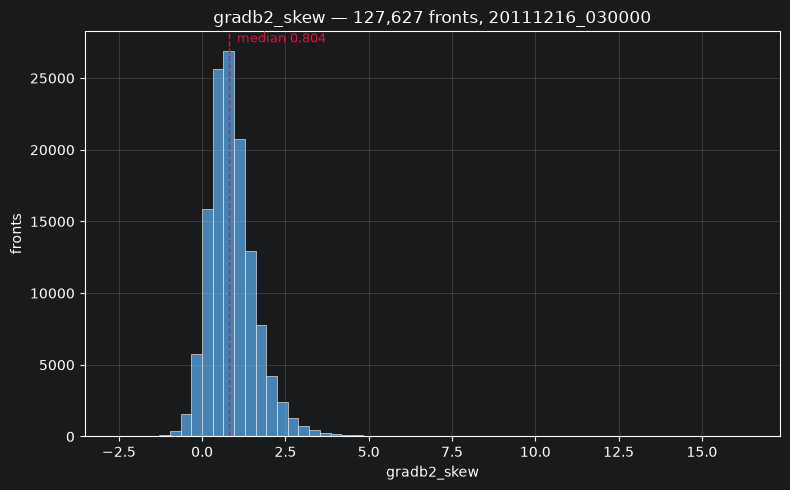

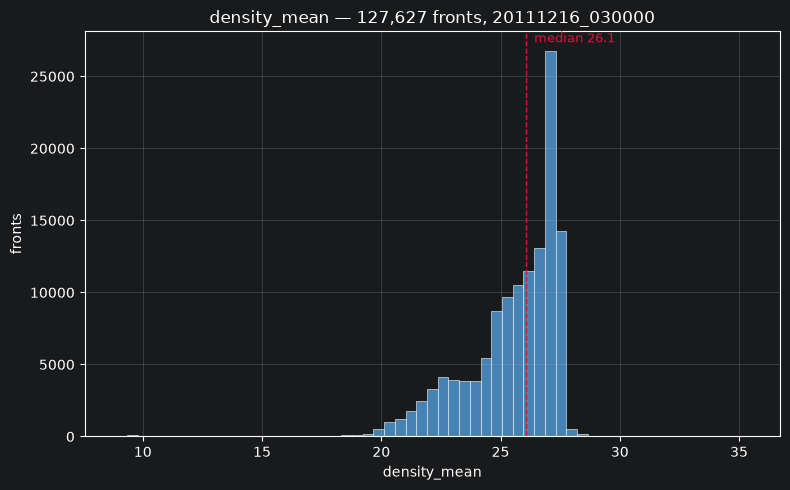

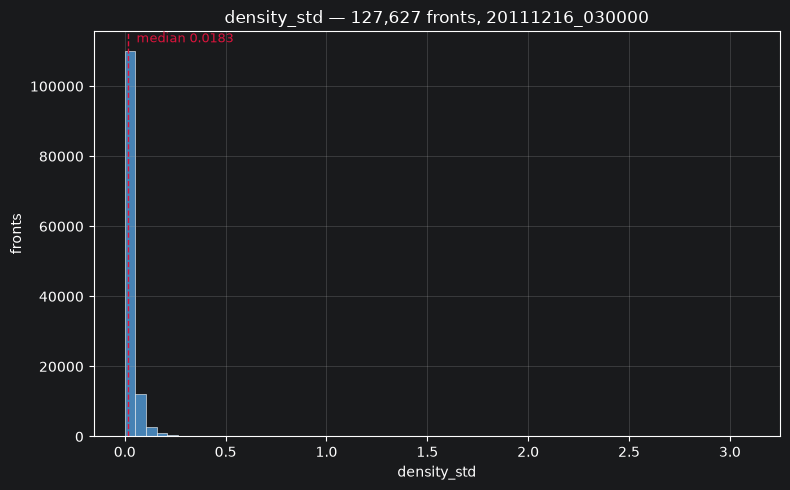

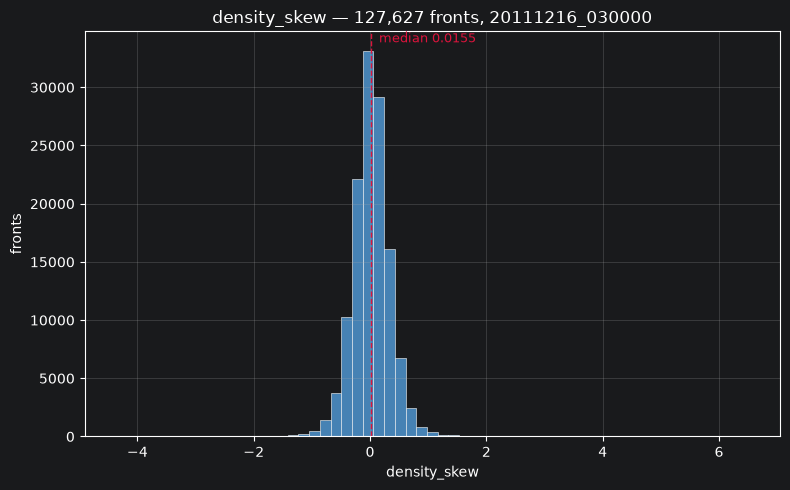

In [30]:
plot_cols = [("length_km", False), ("mean_curvature", False), ("gradb2_mean", True), ("gradb2_std", True), ("gradb2_skew", False),("density_mean", False), ("density_std", False), ("density_skew", False)]


for c in plot_cols:
    plot_property_distribution(store, DATE, c[0], log=c[1], bins=60, ax=None)

In [13]:
fronts.columns

Index(['label', 'name', 'time', 'npix', 'y0', 'y1', 'x0', 'x1', 'centroid_lat',
       'centroid_lon',
       ...
       'cross_density_median', 'cross_density_p25', 'cross_density_p75',
       'cross_density_p90', 'cross_buoyancy_mean', 'cross_buoyancy_std',
       'cross_buoyancy_median', 'cross_buoyancy_p25', 'cross_buoyancy_p75',
       'cross_buoyancy_p90'],
      dtype='str', length=117)

In [14]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm, Normalize

R_EARTH_KM = 6371.0


def _cell_area_km2(lat_edges, lon_edges):
    """Area of each lat/lon box.  Equal-degree cells are not equal-area."""
    dlon = np.deg2rad(np.diff(lon_edges))
    dsin = np.diff(np.sin(np.deg2rad(lat_edges)))
    return R_EARTH_KM ** 2 * np.outer(dsin, dlon)


def plot_front_map(fronts, value=None, resolution=2.0, per_area=True,
                   log=True, projection=None, cmap="magma", ax=None,
                   vmin=None, vmax=None):
    """Binned map of front centroids on the globe.

    Parameters
    ----------
    fronts : pandas.DataFrame
        Output of ``store.fronts(date)`` or ``store.dataset()``.  Needs
        ``centroid_lat`` and ``centroid_lon``.
    value : str, optional
        Column to sum in each cell, e.g. ``'length_km'``.  Default counts
        fronts.
    resolution : float
        Bin size in degrees.
    per_area : bool
        Divide by cell area, giving a density per 1000 km^2.  Equal-degree
        cells shrink towards the poles, so raw counts understate polar density
        by a factor of ~5 at 78 degrees.
    log : bool
        Log colour scale.  Empty cells are masked either way.
    projection : cartopy CRS, optional
        Defaults to Robinson.

    Returns
    -------
    (matplotlib.axes.Axes, matplotlib.collections.QuadMesh)
    """
    lat = fronts["centroid_lat"].to_numpy(float)
    lon = fronts["centroid_lon"].to_numpy(float)
    ok = np.isfinite(lat) & np.isfinite(lon)
    weights = None
    if value is not None:
        w = fronts[value].to_numpy(float)
        ok &= np.isfinite(w)
        weights = w[ok]
    lat, lon = lat[ok], lon[ok]

    lat_edges = np.arange(-90, 90 + resolution, resolution)
    lon_edges = np.arange(-180, 180 + resolution, resolution)
    H, _, _ = np.histogram2d(lat, lon, bins=[lat_edges, lon_edges],
                             weights=weights)

    unit = "fronts" if value is None else value
    if per_area:
        H = H / (_cell_area_km2(lat_edges, lon_edges) / 1e3)
        unit += " / 1000 km$^2$"
    H = np.ma.masked_equal(H, 0)

    if ax is None:
        _, ax = plt.subplots(
            figsize=(13, 6.5),
            subplot_kw={"projection": projection or ccrs.Robinson()})
    norm = (LogNorm(vmin=vmin or H.min(), vmax=vmax or H.max()) if log
            else Normalize(vmin=vmin, vmax=vmax))
    mesh = ax.pcolormesh(lon_edges, lat_edges, H, transform=ccrs.PlateCarree(),
                         cmap=cmap, norm=norm, shading="flat")

    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
    ax.coastlines(linewidth=0.4, color="0.4", zorder=3)
    ax.gridlines(linewidth=0.3, color="0.7", alpha=0.5)
    ax.set_global()

    cb = ax.figure.colorbar(mesh, ax=ax, orientation="vertical",
                            shrink=0.72, pad=0.02,
                            extend="both" if (vmin or vmax) else "neither")
    cb.set_label(unit)
    ax.set_title(f"{len(lat):,} fronts, {resolution}° bins")
    ax.figure.tight_layout()
    return ax, mesh

(<GeoAxes: title={'center': '111,654 fronts, 1.0° bins'}>,
 <cartopy.mpl.geocollection.GeoQuadMesh at 0x43ee43cb0>)

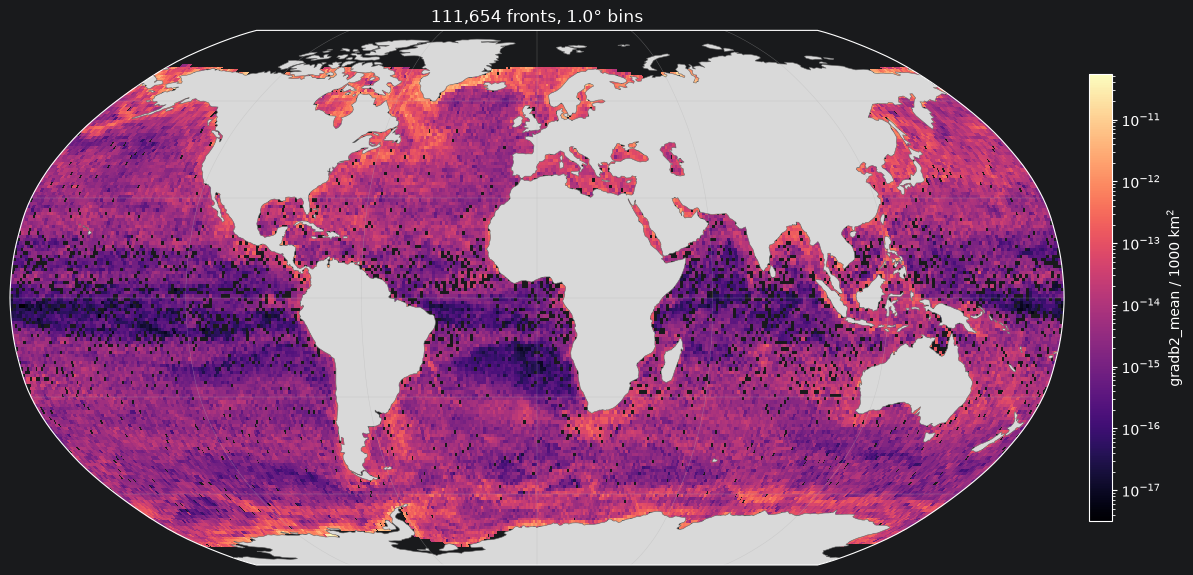

In [15]:
plot_front_map(store.fronts(DATE), value="gradb2_mean", resolution=1.0)

In [22]:
import numpy as np
import pandas as pd
from scipy import ndimage


def find_closed_fronts(store, date=None, window=None, min_hole=5,
                       min_circularity=0.5):
    """Closed fronts -- candidate eddies -- in a snapshot.

    A closed front encloses a background region that does not touch the frame.
    Circularity is 4*pi*A / P^2 over the LOOP's own boundary, not the whole
    connected component: a small ring hanging off a long meandering front is
    one component, so scoring the component would call every real ring
    non-circular.  1.0 is a perfect circle.

    window is (y0, y1, x0, x1).  The whole grid is 224 M px and this labels the
    background, so a window is strongly advised.
    """
    date = date or store.dates[0]
    binary = np.asarray(store.binary(date, window=window)
                        if window else store.binary(date)[:])
    y0, x0 = (window[0], window[2]) if window else (0, 0)
    labels = np.asarray(store.labels(date, window=window)
                        if window else store.labels(date)[:])

    bg, _ = ndimage.label(~binary)
    # A hole touching the frame is open water, not an enclosure.
    edge = set(np.unique(np.r_[bg[0], bg[-1], bg[:, 0], bg[:, -1]]))

    rows = []
    for hid, area in enumerate(np.bincount(bg.ravel())):
        if hid == 0 or hid in edge or area < min_hole:
            continue
        hole = bg == hid
        loop = ndimage.binary_dilation(hole, np.ones((3, 3))) & binary
        perim = int(loop.sum())
        circ = 4 * np.pi * area / (perim ** 2) if perim else 0.0
        if circ < min_circularity:
            continue
        owners = np.unique(labels[loop])
        owners = owners[owners > 0]
        ys, xs = np.where(hole)
        rows.append({
            "label": int(owners[0]) if len(owners) == 1 else -1,
            "n_fronts": len(owners),
            "hole_px": int(area),
            "loop_px": perim,
            "circularity": round(float(circ), 3),
            "j": int(ys.mean()) + y0,
            "i": int(xs.mean()) + x0,
        })
    return (pd.DataFrame(rows)
            .sort_values("circularity", ascending=False)
            .reset_index(drop=True))

In [23]:
find_closed_fronts(store, window=(5600, 6300, 2400, 3100), min_hole=15)

,label,n_fronts,hole_px,loop_px,circularity,j,i
0,47356,1,17,16,0.834,5866,2805
1,49160,1,17,16,0.834,6022,2445
2,45808,1,19,17,0.826,5781,2776
3,47861,1,21,18,0.814,5934,2564
4,52991,1,30,22,0.779,6249,2473
5,46768,1,26,21,0.741,5836,2767
6,50521,1,16,17,0.696,6131,2659
7,46340,1,17,18,0.659,5795,2580
8,49219,1,30,24,0.654,5986,2759
9,47950,1,16,18,0.621,5895,3091
